# 🏎️ Box Box Box — EDA from Parquet Files

This notebook loads the **pre-processed parquet files** from `data/processed/` and performs
an in-depth Exploratory Data Analysis to understand the F1 race simulation mechanics.

| File | Description |
|------|-------------|
| `races.parquet` | One row per historical race (30 000 races) |
| `stints.parquet` | One row per tire stint per driver per race |
| `test_races.parquet` | 100 test-case race configs |
| `test_stints.parquet` | Tire-stint detail for the 100 test cases |

> **Prerequisite**: Run `explore_data.ipynb` once to generate the parquet files (they likely already exist in `data/processed/`).

---
## §0 — Imports & Config

In [8]:
from pathlib import Path

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns

# ── Paths ────────────────────────────────────────────────────────────────────
REPO_ROOT   = Path("../")
PROC_DIR    = REPO_ROOT / "data" / "processed"

# ── Plot aesthetics ───────────────────────────────────────────────────────────
sns.set_theme(style="darkgrid", palette="muted", font_scale=1.1)
plt.rcParams["figure.figsize"] = (13, 5)
plt.rcParams["figure.dpi"]     = 110

TIRE_COLORS = {"SOFT": "#E8002D", "MEDIUM": "#FFF500", "HARD": "#DDDDDD"}
TIRE_ORDER  = ["SOFT", "MEDIUM", "HARD"]

print("Imports OK ✅")
for p in sorted(PROC_DIR.glob("*.parquet")):
    print(f"  {p.name}  ({p.stat().st_size / 1024:.0f} KB)")

Imports OK ✅
  races.parquet  (315 KB)
  stints.parquet  (4938 KB)
  test_races.parquet  (6 KB)
  test_stints.parquet  (29 KB)


---
## §1 — Load Parquet Files

In [9]:
import pyarrow.parquet as pq

def read_parquet(path):
    """Read parquet via pyarrow directly, bypassing pandas extension-type
    metadata (ArrowKeyError: arrow.py_extension_type) that occurs when the
    file was saved with an older pyarrow + pandas Categorical / Int64."""
    return pq.read_table(str(path)).to_pandas()

df_races        = read_parquet(PROC_DIR / "races.parquet")
df_stints       = read_parquet(PROC_DIR / "stints.parquet")
df_test_races   = read_parquet(PROC_DIR / "test_races.parquet")
df_test_stints  = read_parquet(PROC_DIR / "test_stints.parquet")

# Restore ordered categorical on tire compound (lost without pandas metadata)
for df in [df_stints, df_test_stints]:
    df["tire_compound"] = pd.Categorical(
        df["tire_compound"].astype(str), categories=TIRE_ORDER, ordered=True
    )

# finishing_pos comes back as float64 from Arrow (nullable Int64 → double); cast back
for df in [df_stints, df_test_stints]:
    df["finishing_pos"] = df["finishing_pos"].astype("Int64")

print(f"df_races       : {df_races.shape}")
print(f"df_stints      : {df_stints.shape}")
print(f"df_test_races  : {df_test_races.shape}")
print(f"df_test_stints : {df_test_stints.shape}")

df_races       : (30000, 6)
df_stints      : (1253979, 15)
df_test_races  : (100, 6)
df_test_stints : (4174, 15)


### 1.1  Schema & Sample Rows

In [10]:
print("=== df_races — dtypes ===")
display(df_races.dtypes.to_frame("dtype"))
display(df_races.head(3))

=== df_races — dtypes ===


,dtype
race_id,str
track,str
total_laps,int32
base_lap_time,float64
pit_lane_time,float64
track_temp,int32


,race_id,track,total_laps,base_lap_time,pit_lane_time,track_temp
0,R21072,Suzuka,50,84.5,22.7,27
1,R05618,Suzuka,40,86.7,20.6,30
2,R11409,Monza,36,82.9,21.3,33


In [11]:
print("=== df_stints — dtypes ===")
display(df_stints.dtypes.to_frame("dtype"))
display(df_stints.head(6))

=== df_stints — dtypes ===


,dtype
race_id,str
track,str
total_laps,int64
base_lap_time,float64
pit_lane_time,float64
track_temp,int64
driver_id,str
starting_grid_pos,int64
finishing_pos,Int64
num_pitstops,int64


,race_id,track,total_laps,base_lap_time,pit_lane_time,track_temp,driver_id,starting_grid_pos,finishing_pos,num_pitstops,stint_number,tire_compound,stint_start_lap,stint_end_lap,stint_laps
0,R21072,Suzuka,50,84.5,22.7,27,D001,1,1,1,1,MEDIUM,1,23,23
1,R21072,Suzuka,50,84.5,22.7,27,D001,1,1,1,2,HARD,24,50,27
2,R21072,Suzuka,50,84.5,22.7,27,D002,2,4,2,1,MEDIUM,1,12,12
3,R21072,Suzuka,50,84.5,22.7,27,D002,2,4,2,2,HARD,13,29,17
4,R21072,Suzuka,50,84.5,22.7,27,D002,2,4,2,3,MEDIUM,30,50,21
5,R21072,Suzuka,50,84.5,22.7,27,D003,3,13,1,1,SOFT,1,15,15


---
## §2 — Race-Level Summary Statistics

In [12]:
print("=== Descriptive stats — race configs ===")
display(df_races[["total_laps", "base_lap_time", "pit_lane_time", "track_temp"]].describe().round(3))

=== Descriptive stats — race configs ===


,total_laps,base_lap_time,pit_lane_time,track_temp
count,30000.000,30000.000,30000.000,30000.000
mean,45.517,87.501,22.000,30.305
std,10.365,4.336,1.157,4.579
min,25.000,80.000,20.000,18.000
25%,38.000,83.700,21.000,28.000
50%,45.000,87.500,22.000,30.000
75%,52.000,91.300,23.000,33.000
max,70.000,95.000,24.000,42.000


### 2.1  Races per Track

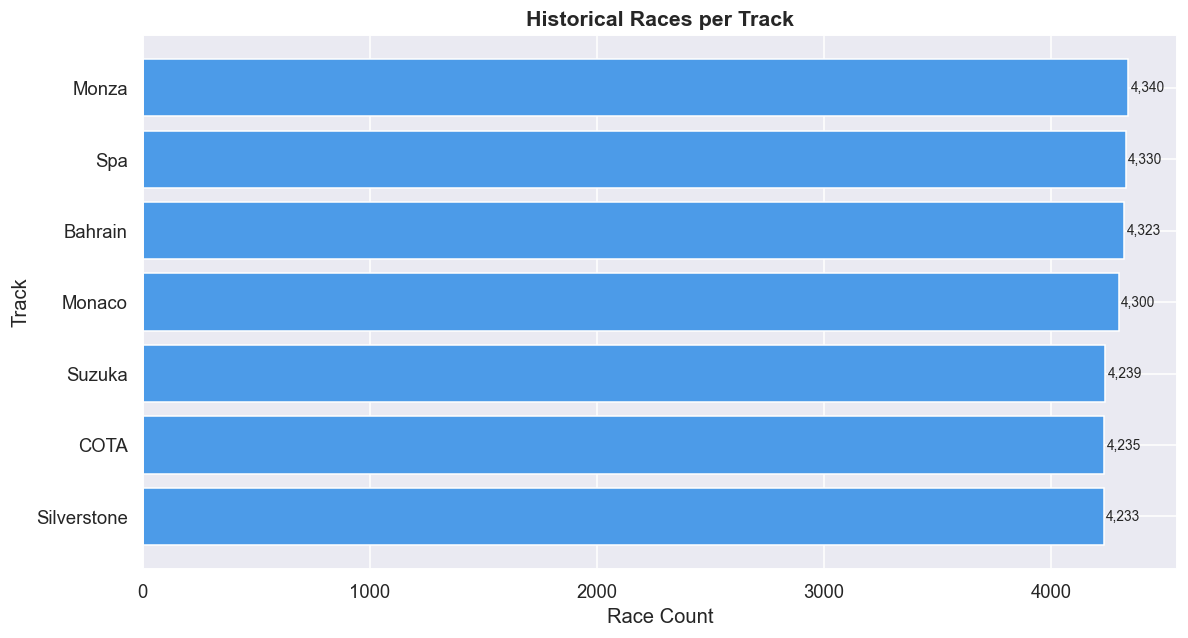

track
Silverstone    4233
COTA           4235
Suzuka         4239
Monaco         4300
Bahrain        4323
Spa            4330
Monza          4340


In [13]:
track_counts = df_races["track"].value_counts().sort_values()

fig, ax = plt.subplots(figsize=(11, 6))
bars = ax.barh(track_counts.index, track_counts.values, color="#4C9BE8", edgecolor="white")
for bar in bars:
    ax.text(bar.get_width() + 10, bar.get_y() + bar.get_height() / 2,
            f"{int(bar.get_width()):,}", va="center", fontsize=9)
ax.set_title("Historical Races per Track", fontweight="bold", fontsize=14)
ax.set_xlabel("Race Count")
ax.set_ylabel("Track")
plt.tight_layout()
plt.show()
print(track_counts.to_string())

### 2.2  Track Temperature Distribution

C:\Users\Xenon\AppData\Local\Temp\ipykernel_11376\2066491178.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_races, x="track_temp", y="track", order=order,


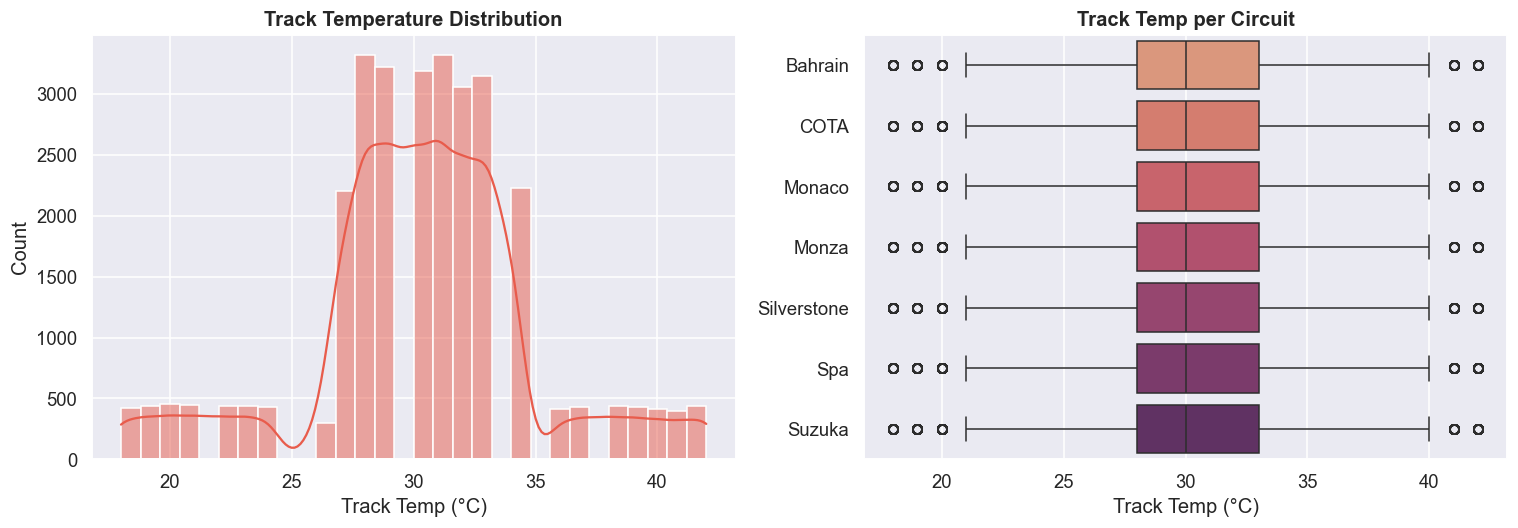

              count  mean  std   min   25%   50%   75%   max
track                                                       
Bahrain      4323.0  30.3  4.6  18.0  28.0  30.0  33.0  42.0
COTA         4235.0  30.3  4.6  18.0  28.0  30.0  33.0  42.0
Monaco       4300.0  30.4  4.6  18.0  28.0  30.0  33.0  42.0
Monza        4340.0  30.2  4.5  18.0  28.0  30.0  33.0  42.0
Silverstone  4233.0  30.4  4.6  18.0  28.0  30.0  33.0  42.0
Spa          4330.0  30.3  4.6  18.0  28.0  30.0  33.0  42.0
Suzuka       4239.0  30.3  4.5  18.0  28.0  30.0  33.0  42.0


In [14]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram + KDE
sns.histplot(df_races["track_temp"], bins=30, kde=True, ax=axes[0], color="#E85C4C")
axes[0].set_title("Track Temperature Distribution", fontweight="bold")
axes[0].set_xlabel("Track Temp (°C)")

# Box plot per track (ordered by median temp)
order = df_races.groupby("track")["track_temp"].median().sort_values().index
sns.boxplot(data=df_races, x="track_temp", y="track", order=order,
            ax=axes[1], palette="flare")
axes[1].set_title("Track Temp per Circuit", fontweight="bold")
axes[1].set_xlabel("Track Temp (°C)")
axes[1].set_ylabel("")

plt.tight_layout()
plt.show()
print(df_races.groupby("track")["track_temp"].describe().round(1))

### 2.3  Base Lap Time & Pit Lane Time per Track

base_lap_time                   pit_lane_time                  
                     mean   std   min   max          mean   std   min   max
track                                                                      
Bahrain             87.46  4.27  80.0  95.0         22.00  1.16  20.0  24.0
COTA                87.59  4.33  80.0  95.0         21.99  1.16  20.0  24.0
Monaco              87.42  4.31  80.0  95.0         21.98  1.15  20.0  24.0
Monza               87.52  4.37  80.0  95.0         22.02  1.16  20.0  24.0
Silverstone         87.49  4.36  80.0  95.0         22.02  1.16  20.0  24.0
Spa                 87.46  4.36  80.0  95.0         22.00  1.16  20.0  24.0
Suzuka              87.56  4.36  80.0  95.0         21.98  1.15  20.0  24.0

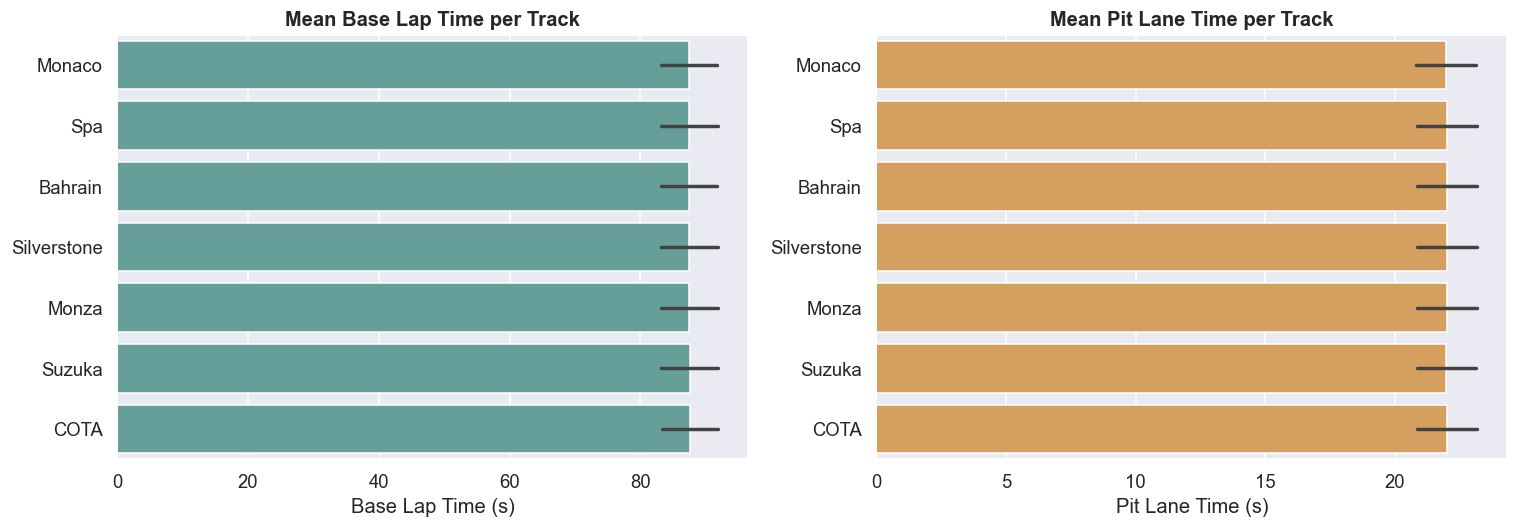

In [15]:
track_stats = df_races.groupby("track")[["base_lap_time", "pit_lane_time"]].agg(["mean", "std", "min", "max"]).round(2)
display(track_stats)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
order_plt = df_races.groupby("track")["base_lap_time"].mean().sort_values().index

sns.barplot(data=df_races, x="base_lap_time", y="track", order=order_plt,
            estimator="mean", errorbar="sd", ax=axes[0], color="#5DA8A0")
axes[0].set_title("Mean Base Lap Time per Track", fontweight="bold")
axes[0].set_xlabel("Base Lap Time (s)")
axes[0].set_ylabel("")

sns.barplot(data=df_races, x="pit_lane_time", y="track", order=order_plt,
            estimator="mean", errorbar="sd", ax=axes[1], color="#E8A24C")
axes[1].set_title("Mean Pit Lane Time per Track", fontweight="bold")
axes[1].set_xlabel("Pit Lane Time (s)")
axes[1].set_ylabel("")

plt.tight_layout()
plt.show()

---
## §3 — Stint-Level Analysis

### 3.1  Tire Compound Usage

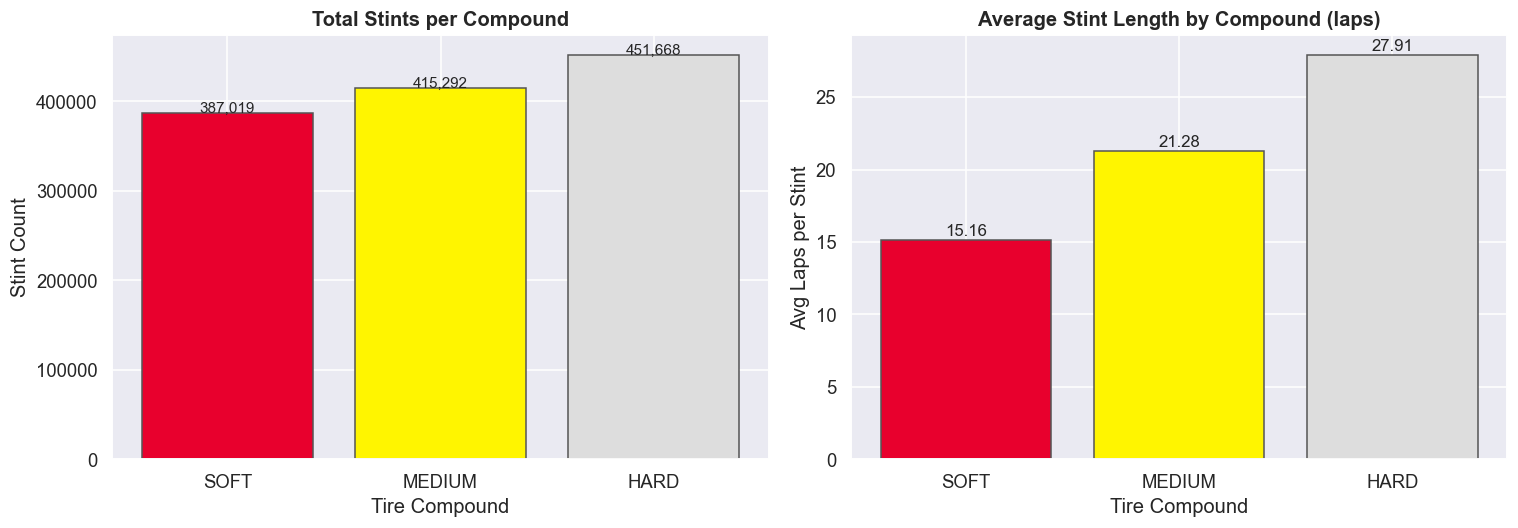

Avg stint lengths:
tire_compound
SOFT      15.162
MEDIUM    21.281
HARD      27.906


In [16]:
compound_counts = df_stints["tire_compound"].value_counts().reindex(TIRE_ORDER)
colors = [TIRE_COLORS[c] for c in compound_counts.index]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].bar(compound_counts.index, compound_counts.values, color=colors, edgecolor="#555")
axes[0].set_title("Total Stints per Compound", fontweight="bold")
axes[0].set_xlabel("Tire Compound")
axes[0].set_ylabel("Stint Count")
for x, v in zip(compound_counts.index, compound_counts.values):
    axes[0].text(x, v + 500, f"{v:,}", ha="center", fontsize=10)

avg_stint = df_stints.groupby("tire_compound", observed=True)["stint_laps"].mean().reindex(TIRE_ORDER)
axes[1].bar(avg_stint.index, avg_stint.values, color=colors, edgecolor="#555")
axes[1].set_title("Average Stint Length by Compound (laps)", fontweight="bold")
axes[1].set_xlabel("Tire Compound")
axes[1].set_ylabel("Avg Laps per Stint")
for x, v in zip(avg_stint.index, avg_stint.values):
    axes[1].text(x, v + 0.3, f"{v:.2f}", ha="center", fontsize=11)

plt.tight_layout()
plt.show()
print("Avg stint lengths:")
print(avg_stint.round(3).to_string())

### 3.2  Stint Length Distribution per Compound

C:\Users\Xenon\AppData\Local\Temp\ipykernel_11376\2921171846.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_stints, x="tire_compound", y="stint_laps",


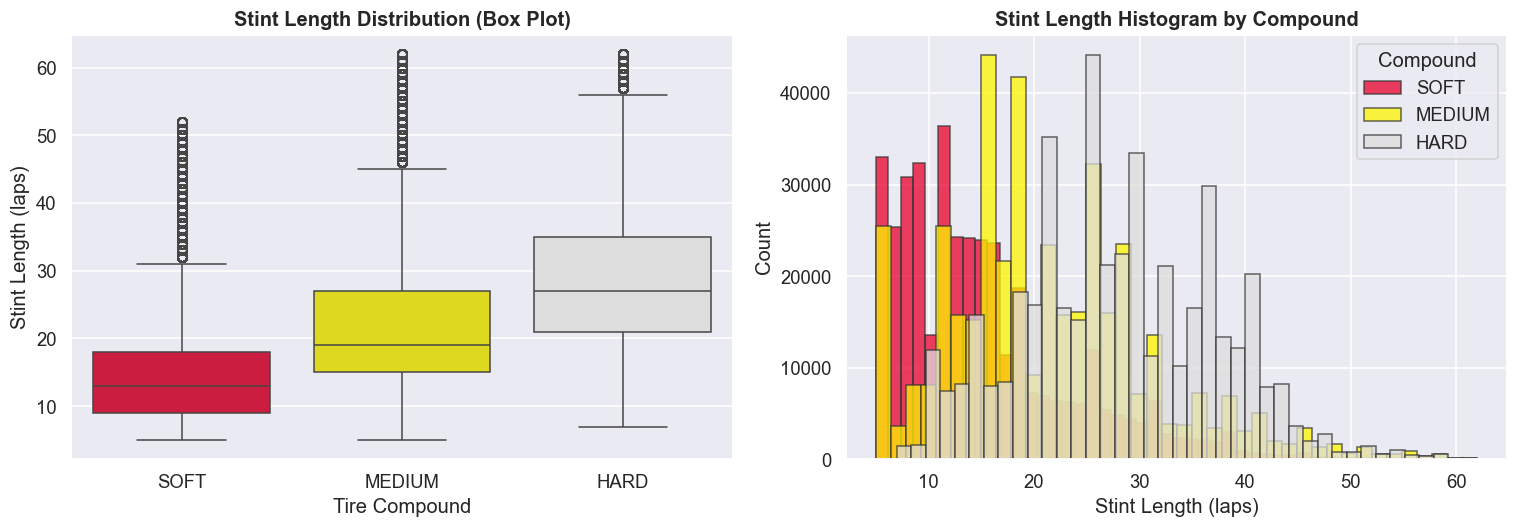

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.boxplot(data=df_stints, x="tire_compound", y="stint_laps",
            order=TIRE_ORDER, palette=TIRE_COLORS, ax=axes[0])
axes[0].set_title("Stint Length Distribution (Box Plot)", fontweight="bold")
axes[0].set_xlabel("Tire Compound")
axes[0].set_ylabel("Stint Length (laps)")

for compound in TIRE_ORDER:
    data = df_stints.loc[df_stints["tire_compound"] == compound, "stint_laps"]
    axes[1].hist(data, bins=40, alpha=0.75, label=compound, color=TIRE_COLORS[compound],
                 edgecolor="#333")
axes[1].set_title("Stint Length Histogram by Compound", fontweight="bold")
axes[1].set_xlabel("Stint Length (laps)")
axes[1].set_ylabel("Count")
axes[1].legend(title="Compound")

plt.tight_layout()
plt.show()

### 3.3  Pit Stop Count Distribution

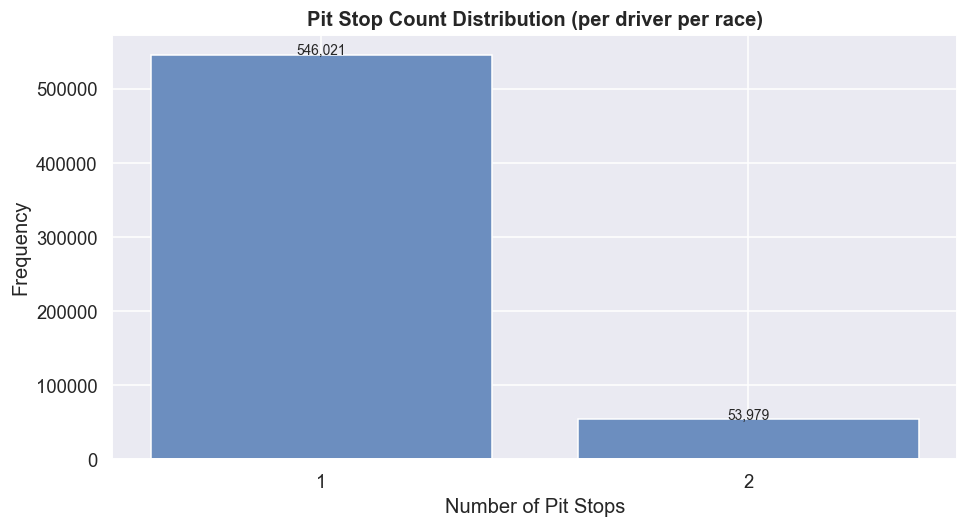

num_pitstops
1    546021
2     53979


In [18]:
stop_dist = (
    df_stints
    .drop_duplicates(["race_id", "driver_id"])
    ["num_pitstops"]
    .value_counts()
    .sort_index()
)

fig, ax = plt.subplots(figsize=(9, 5))
ax.bar(stop_dist.index.astype(str), stop_dist.values, color="#6C8EBF", edgecolor="white")
ax.set_title("Pit Stop Count Distribution (per driver per race)", fontweight="bold")
ax.set_xlabel("Number of Pit Stops")
ax.set_ylabel("Frequency")
for x, v in zip(stop_dist.index, stop_dist.values):
    ax.text(str(x), v + 200, f"{v:,}", ha="center", fontsize=9)
plt.tight_layout()
plt.show()
print(stop_dist.to_string())

---
## §4 — Strategy vs. Outcome Analysis

### 4.1  Starting Tire Compound vs. Finishing Position

C:\Users\Xenon\AppData\Local\Temp\ipykernel_11376\4263018911.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=starting, x="tire_compound", y="finishing_pos",


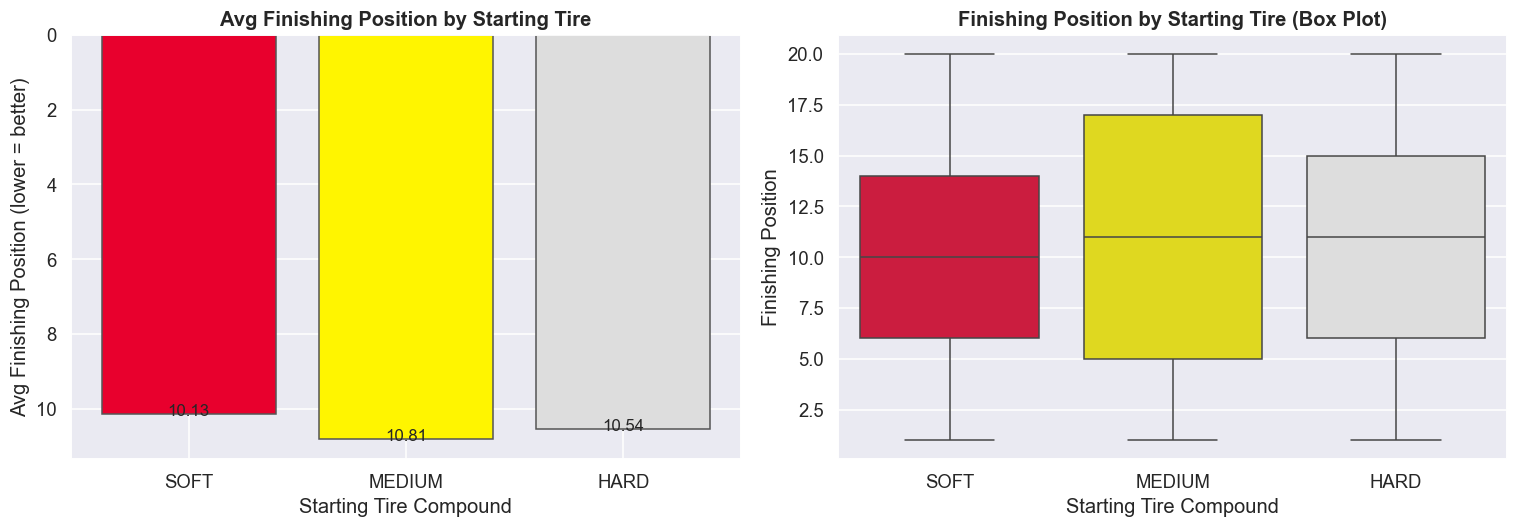

Mean finishing position per starting compound:
tire_compound
SOFT      10.132
MEDIUM    10.813
HARD       10.54


In [19]:
starting = df_stints[df_stints["stint_number"] == 1].copy()
avg_fin  = starting.groupby("tire_compound", observed=True)["finishing_pos"].mean().reindex(TIRE_ORDER)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

colors_list = [TIRE_COLORS[c] for c in avg_fin.index]
axes[0].bar(avg_fin.index, avg_fin.values, color=colors_list, edgecolor="#555")
axes[0].set_title("Avg Finishing Position by Starting Tire", fontweight="bold")
axes[0].set_xlabel("Starting Tire Compound")
axes[0].set_ylabel("Avg Finishing Position (lower = better)")
axes[0].invert_yaxis()
for x, v in zip(avg_fin.index, avg_fin.values):
    axes[0].text(x, v + 0.05, f"{v:.2f}", ha="center", fontsize=11)

sns.boxplot(data=starting, x="tire_compound", y="finishing_pos",
            order=TIRE_ORDER, palette=TIRE_COLORS, ax=axes[1])
axes[1].set_title("Finishing Position by Starting Tire (Box Plot)", fontweight="bold")
axes[1].set_xlabel("Starting Tire Compound")
axes[1].set_ylabel("Finishing Position")

plt.tight_layout()
plt.show()
print("Mean finishing position per starting compound:")
print(avg_fin.round(3).to_string())

### 4.2  Pit Stop Count vs. Finishing Position

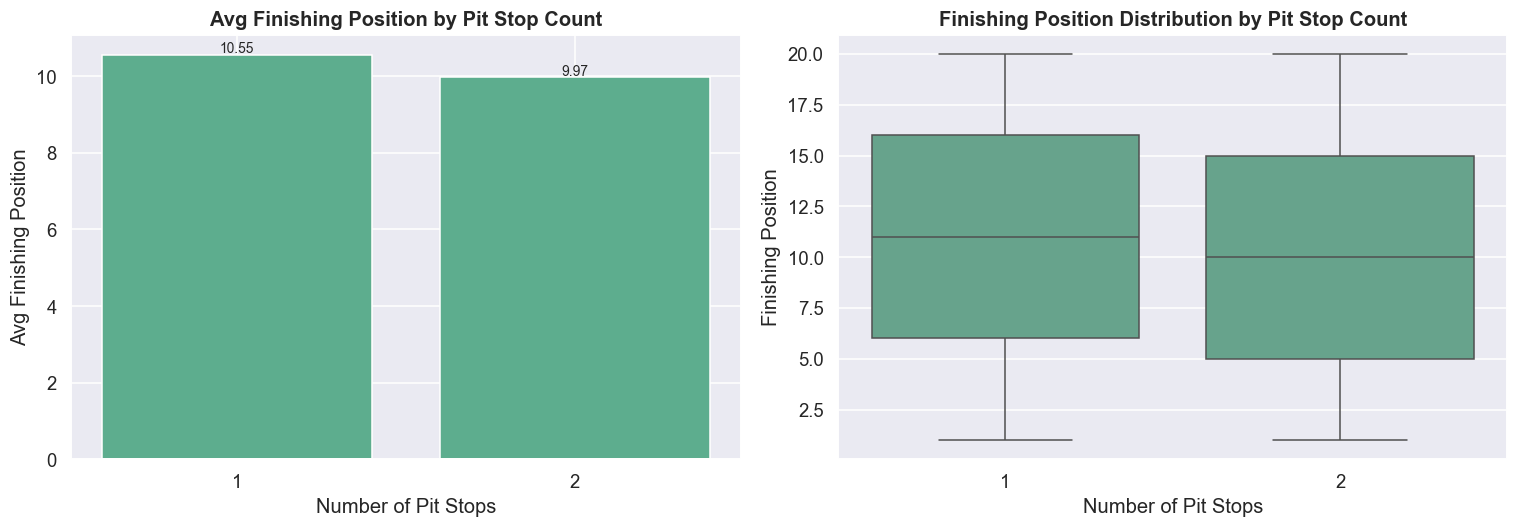

num_pitstops
1    10.553
2     9.966


In [20]:
driver_level = (
    df_stints
    .groupby(["race_id", "driver_id"], observed=True)
    .agg(finishing_pos=("finishing_pos", "first"),
         num_pitstops=("num_pitstops", "first"),
         track=("track", "first"))
    .reset_index()
)

avg_by_stops = driver_level.groupby("num_pitstops")["finishing_pos"].mean()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].bar(avg_by_stops.index.astype(str), avg_by_stops.values,
            color="#5DAD8E", edgecolor="white")
axes[0].set_title("Avg Finishing Position by Pit Stop Count", fontweight="bold")
axes[0].set_xlabel("Number of Pit Stops")
axes[0].set_ylabel("Avg Finishing Position")
for x, v in zip(avg_by_stops.index.astype(str), avg_by_stops.values):
    axes[0].text(x, v + 0.05, f"{v:.2f}", ha="center", fontsize=9)

sns.boxplot(data=driver_level, x="num_pitstops", y="finishing_pos", ax=axes[1],
            color="#5DAD8E")
axes[1].set_title("Finishing Position Distribution by Pit Stop Count", fontweight="bold")
axes[1].set_xlabel("Number of Pit Stops")
axes[1].set_ylabel("Finishing Position")

plt.tight_layout()
plt.show()
print(avg_by_stops.round(3).to_string())

### 4.3  Track Temperature vs. Average Pit Stop Count

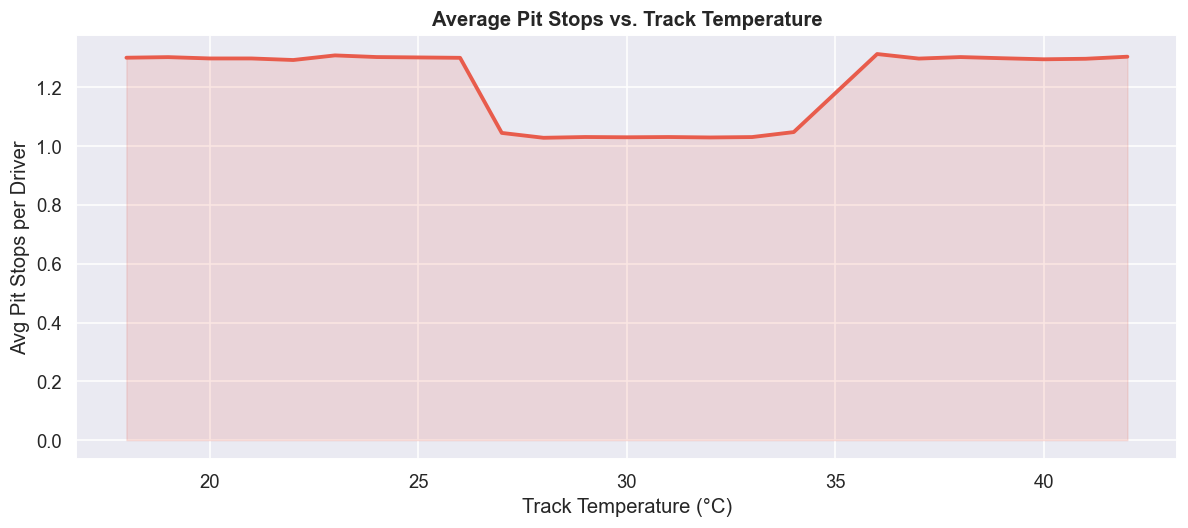

In [21]:
temp_stops = (
    df_stints
    .drop_duplicates(["race_id", "driver_id"])[["track_temp", "num_pitstops"]]
    .groupby("track_temp")["num_pitstops"]
    .mean()
)

fig, ax = plt.subplots(figsize=(11, 5))
ax.plot(temp_stops.index, temp_stops.values, color="#E85C4C", linewidth=2.5)
ax.fill_between(temp_stops.index, temp_stops.values, alpha=0.15, color="#E85C4C")
ax.set_title("Average Pit Stops vs. Track Temperature", fontweight="bold")
ax.set_xlabel("Track Temperature (°C)")
ax.set_ylabel("Avg Pit Stops per Driver")
plt.tight_layout()
plt.show()

---
## §5 — Reverse-Engineering Lap Time Formula

The key insight we want to extract:
- How much faster is **SOFT** vs **MEDIUM** vs **HARD** per lap?
- How fast does each compound **degrade** per lap?
- Does **track temperature** affect degradation?

We approach this by studying which drivers finished 1st — and working backwards from their strategies.

### 5.1  Winner Strategy Profile

In [22]:
winners = df_stints[df_stints["finishing_pos"] == 1].copy()

print(f"Total winner stints: {len(winners):,}  (one stint per race winner compound)")
print()

win_compound = winners["tire_compound"].value_counts().reindex(TIRE_ORDER)
print("Tire compound breakdown across ALL winner stints:")
print(win_compound.to_string())

win_start = winners[winners["stint_number"] == 1]["tire_compound"].value_counts().reindex(TIRE_ORDER)
print()
print("Starting compound of race winners:")
print(win_start.to_string())

Total winner stints: 63,436  (one stint per race winner compound)

Tire compound breakdown across ALL winner stints:
tire_compound
SOFT      14460
MEDIUM    23912
HARD      25064

Starting compound of race winners:
tire_compound
SOFT       8118
MEDIUM    12486
HARD       9396


### 5.2  Compound Speed Offset — Inference via Identical Race Configs

Races with the same `base_lap_time`, `pit_lane_time`, `track_temp`, and `total_laps` but different strategies provide a controlled experiment.

In [23]:
config_cols = ["base_lap_time", "pit_lane_time", "track_temp", "total_laps"]
df_races["config_key"] = df_races[config_cols].astype(str).agg("|".join, axis=1)

config_counts = df_races["config_key"].value_counts()
print(f"Unique race configs    : {len(config_counts):,}")
print(f"Config with most races : {config_counts.iloc[0]:,} races")
print(config_counts.head(10).to_string())

Unique race configs    : 29,815
Config with most races : 2 races
config_key
84.8|21.9|30|54    2
80.9|23.2|30|36    2
93.4|20.2|28|35    2
82.1|23.9|40|55    2
92.6|21.2|30|32    2
81.2|23.3|30|44    2
86.1|23.5|32|37    2
93.8|23.1|30|52    2
89.1|23.4|31|36    2
87.6|20.6|33|43    2


In [24]:
# Focus on 1-stop races for clean compound comparison
one_stop_drivers = driver_level[driver_level["num_pitstops"] == 1][["race_id", "driver_id", "finishing_pos"]]

stints_1stop = df_stints.merge(one_stop_drivers, on=["race_id", "driver_id"])
pivot = (
    stints_1stop
    .pivot_table(index=["race_id", "driver_id", "finishing_pos_y"],
                 columns="stint_number",
                 values=["tire_compound", "stint_laps"],
                 aggfunc="first")
)
pivot.columns = [f"{col[0]}_stint{col[1]}" for col in pivot.columns]
pivot = pivot.reset_index().rename(columns={"finishing_pos_y": "finishing_pos"})
pivot["strategy"] = pivot["tire_compound_stint1"].astype(str) + "→" + pivot["tire_compound_stint2"].astype(str)

print(f"1-stop driver records : {len(pivot):,}")
print()
print("Top 15 most common 1-stop strategies:")
print(pivot["strategy"].value_counts().head(15).to_string())

1-stop driver records : 546,021

Top 15 most common 1-stop strategies:
strategy
MEDIUM→HARD    111611
HARD→MEDIUM    101370
SOFT→HARD      101015
HARD→SOFT       83698
SOFT→MEDIUM     75474
MEDIUM→SOFT     72853


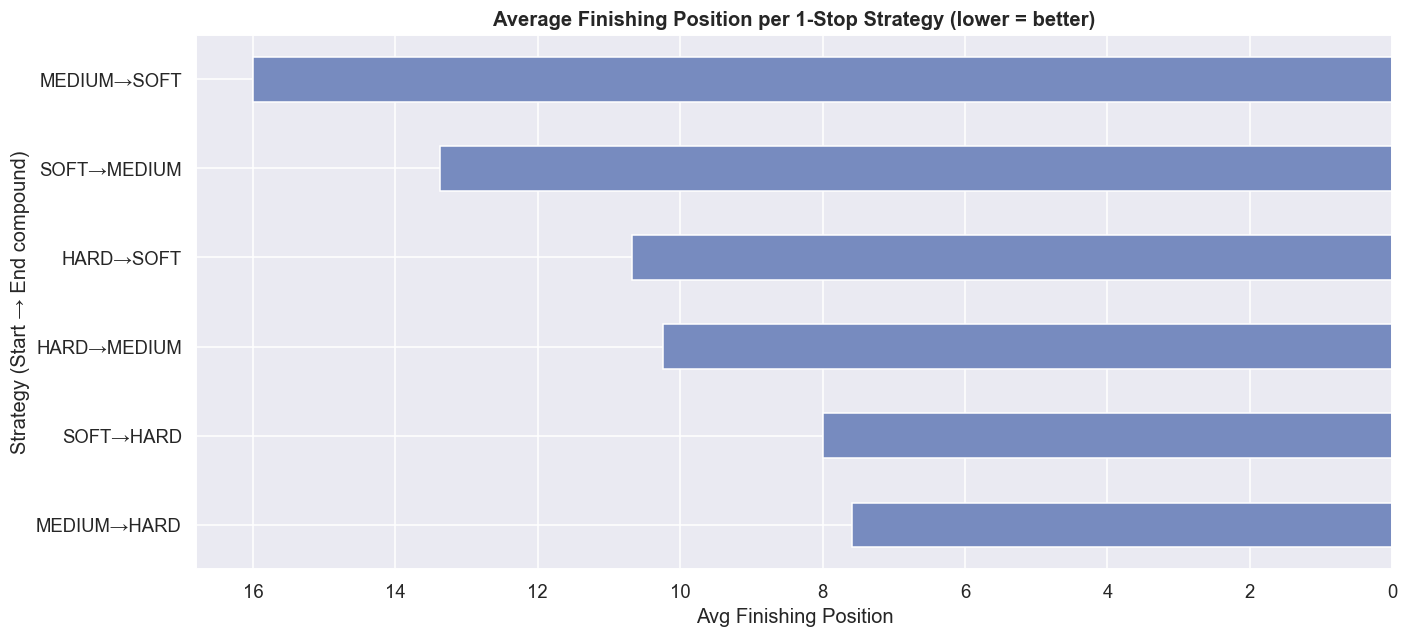

              mean   count
strategy                  
MEDIUM→HARD   7.58  111611
SOFT→HARD      8.0  101015
HARD→MEDIUM  10.24  101370
HARD→SOFT    10.68   83698
SOFT→MEDIUM  13.38   75474
MEDIUM→SOFT  15.99   72853


In [25]:
strat_perf = pivot.groupby("strategy")["finishing_pos"].agg(["mean", "count"]).sort_values("mean")
top_strats = strat_perf[strat_perf["count"] > 50]

fig, ax = plt.subplots(figsize=(13, 6))
top_strats["mean"].plot(kind="barh", ax=ax, color="#778BBF", edgecolor="white")
ax.invert_xaxis()
ax.set_title("Average Finishing Position per 1-Stop Strategy (lower = better)", fontweight="bold")
ax.set_xlabel("Avg Finishing Position")
ax.set_ylabel("Strategy (Start → End compound)")
plt.tight_layout()
plt.show()
print(top_strats.round(2).to_string())

### 5.3  When Do Winners Pit? (Stint Length Optimisation)

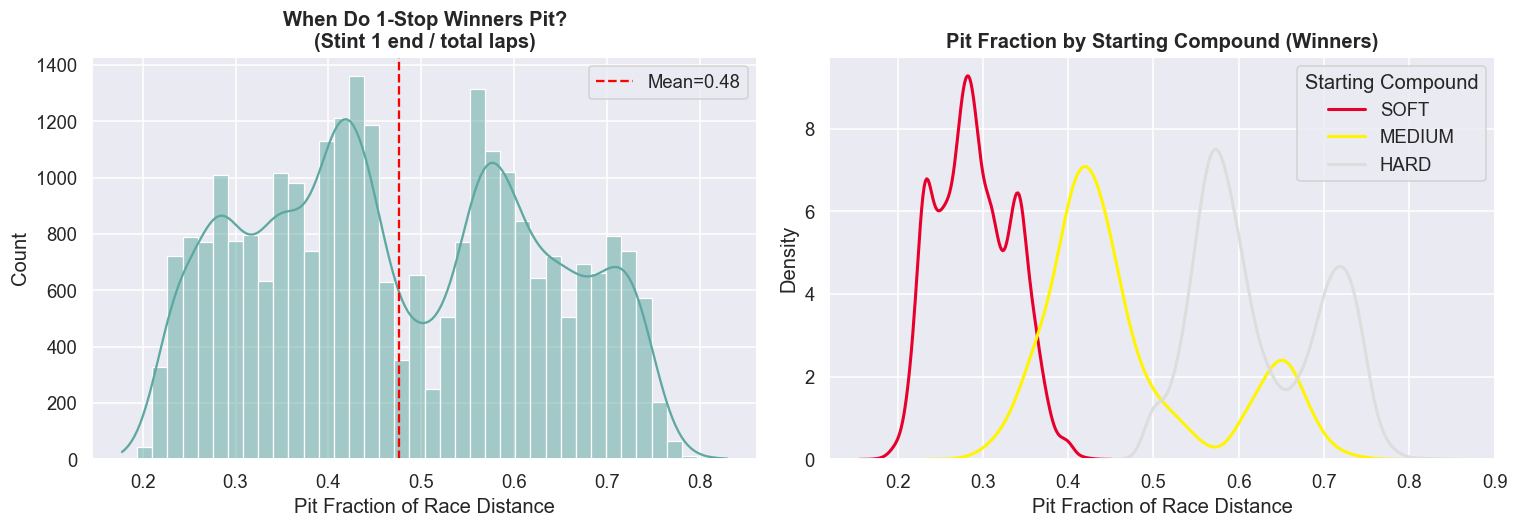

count    26564.000
mean         0.476
std          0.151
min          0.178
25%          0.351
50%          0.452
75%          0.600
max          0.829
Name: pit_fraction, dtype: float64


In [26]:
winners_1stop = df_stints[
    (df_stints["finishing_pos"] == 1) &
    (df_stints["num_pitstops"] == 1) &
    (df_stints["stint_number"] == 1)
].copy()

winners_1stop["pit_fraction"] = winners_1stop["stint_end_lap"] / winners_1stop["total_laps"]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(winners_1stop["pit_fraction"], bins=40, kde=True, ax=axes[0], color="#5DA8A0")
axes[0].set_title("When Do 1-Stop Winners Pit?\n(Stint 1 end / total laps)", fontweight="bold")
axes[0].set_xlabel("Pit Fraction of Race Distance")
axes[0].axvline(winners_1stop["pit_fraction"].mean(), color="red", linestyle="--",
                label=f"Mean={winners_1stop['pit_fraction'].mean():.2f}")
axes[0].legend()

for compound in TIRE_ORDER:
    subset = winners_1stop[winners_1stop["tire_compound"] == compound]["pit_fraction"]
    if len(subset) > 10:
        sns.kdeplot(subset, ax=axes[1], label=compound, color=TIRE_COLORS[compound], linewidth=2)
axes[1].set_title("Pit Fraction by Starting Compound (Winners)", fontweight="bold")
axes[1].set_xlabel("Pit Fraction of Race Distance")
axes[1].legend(title="Starting Compound")

plt.tight_layout()
plt.show()
print(winners_1stop["pit_fraction"].describe().round(3))

---
## §6 — Correlation Heatmap

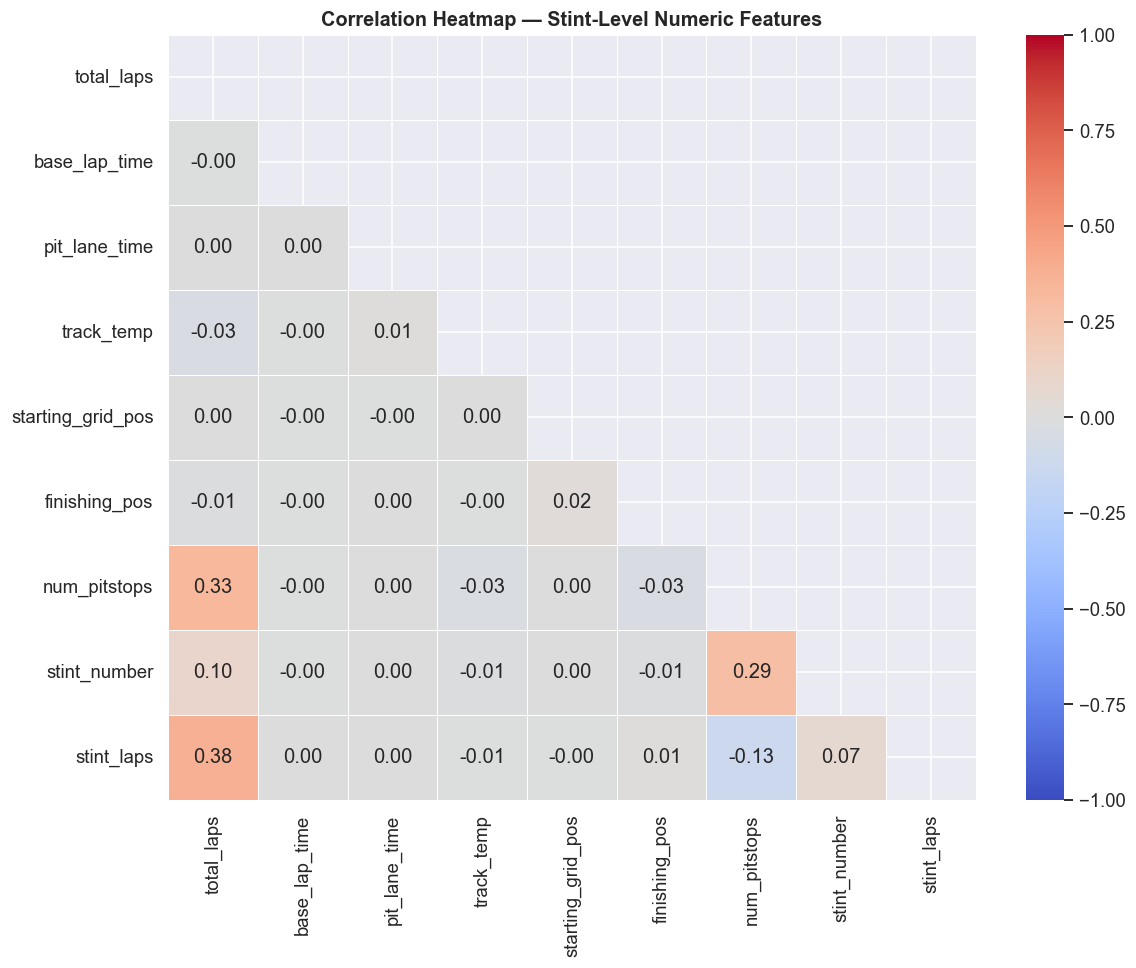

In [27]:
numeric_df = df_stints[[
    "total_laps", "base_lap_time", "pit_lane_time", "track_temp",
    "starting_grid_pos", "finishing_pos", "num_pitstops",
    "stint_number", "stint_laps"
]].copy()

# finishing_pos is nullable Int64 — cast to float for corr()
numeric_df["finishing_pos"] = numeric_df["finishing_pos"].astype(float)

corr = numeric_df.corr()

fig, ax = plt.subplots(figsize=(11, 9))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt=".2f", cmap="coolwarm",
            linewidths=0.5, ax=ax, center=0, vmin=-1, vmax=1)
ax.set_title("Correlation Heatmap — Stint-Level Numeric Features", fontweight="bold", fontsize=13)
plt.tight_layout()
plt.show()

---
## §7 — Test Cases vs. Historical Comparison

In [28]:
print("=== Test Race Config Overview ===")
display(df_test_races[["total_laps", "base_lap_time", "pit_lane_time", "track_temp"]].describe().round(2))
print(f"\nUnique tracks in test set : {df_test_races['track'].nunique()}")
print(df_test_races["track"].value_counts().to_string())

=== Test Race Config Overview ===


,total_laps,base_lap_time,pit_lane_time,track_temp
count,100.00,100.00,100.00,100.00
mean,45.34,86.97,22.02,30.11
std,9.54,4.62,1.14,4.87
min,27.00,80.10,20.10,18.00
25%,39.00,82.57,20.98,28.00
50%,44.50,87.00,22.05,30.00
75%,51.25,91.48,23.00,33.00
max,69.00,94.90,23.90,42.00



Unique tracks in test set : 7
track
Monza          19
Suzuka         18
Monaco         16
Bahrain        13
Silverstone    12
Spa            12
COTA           10


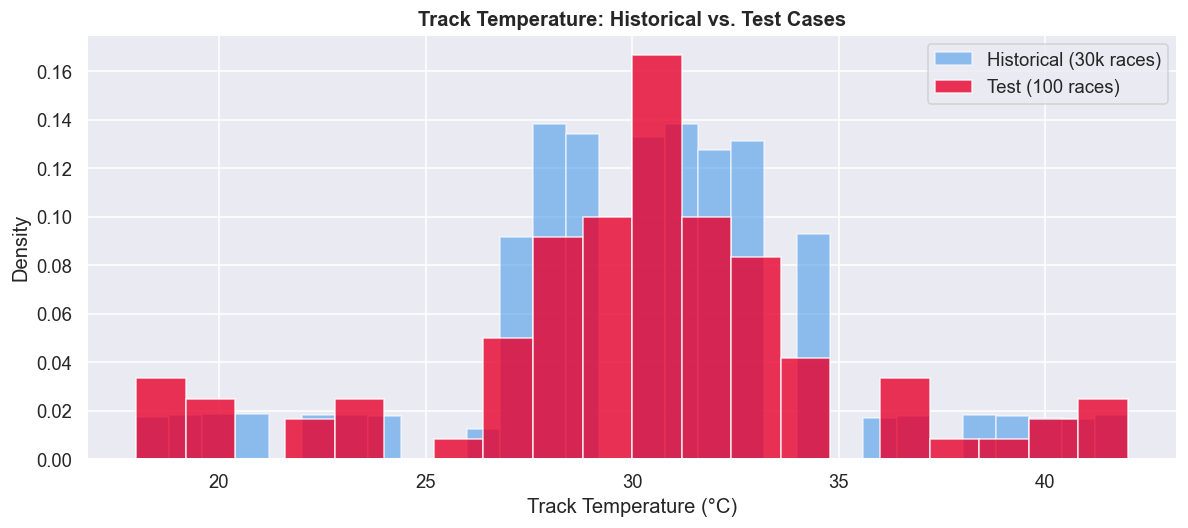

In [29]:
fig, ax = plt.subplots(figsize=(11, 5))
ax.hist(df_races["track_temp"], bins=30, alpha=0.6, label="Historical (30k races)",
        color="#4C9BE8", density=True)
ax.hist(df_test_races["track_temp"], bins=20, alpha=0.8, label="Test (100 races)",
        color="#E8002D", density=True)
ax.set_title("Track Temperature: Historical vs. Test Cases", fontweight="bold")
ax.set_xlabel("Track Temperature (°C)")
ax.set_ylabel("Density")
ax.legend()
plt.tight_layout()
plt.show()

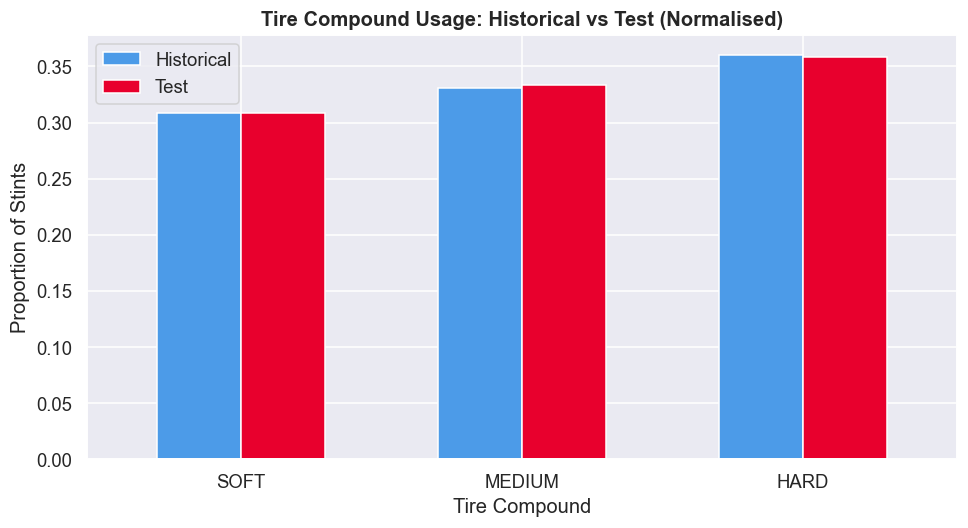

               Historical   Test
tire_compound                   
SOFT                0.309  0.309
MEDIUM              0.331  0.333
HARD                0.360  0.358


In [30]:
test_compound = df_test_stints["tire_compound"].value_counts().reindex(TIRE_ORDER)
hist_compound = df_stints["tire_compound"].value_counts().reindex(TIRE_ORDER)

comp_df = pd.DataFrame({"Historical": hist_compound / hist_compound.sum(),
                        "Test"       : test_compound  / test_compound.sum()})

comp_df.plot(kind="bar", rot=0, figsize=(9, 5), color=["#4C9BE8", "#E8002D"],
             edgecolor="white", width=0.6)
plt.title("Tire Compound Usage: Historical vs Test (Normalised)", fontweight="bold")
plt.xlabel("Tire Compound")
plt.ylabel("Proportion of Stints")
plt.legend()
plt.tight_layout()
plt.show()
print(comp_df.round(3).to_string())

---
## §8 — Track-Specific Deep-Dive (interactive)

Change `FOCUS_TRACK` to any circuit name to re-run this section on a different track.

In [31]:
FOCUS_TRACK = df_races["track"].value_counts().idxmax()   # default: most common track
print(f"Focusing on track: {FOCUS_TRACK}")

track_stints = df_stints[df_stints["track"] == FOCUS_TRACK].copy()
track_races  = df_races[df_races["track"] == FOCUS_TRACK].copy()

print(f"Races      : {len(track_races):,}")
print(f"Stints     : {len(track_stints):,}")
display(track_races[["total_laps", "base_lap_time", "pit_lane_time", "track_temp"]].describe().round(2))

Focusing on track: Monza
Races      : 4,340
Stints     : 181,494


,total_laps,base_lap_time,pit_lane_time,track_temp
count,4340.00,4340.00,4340.00,4340.00
mean,45.57,87.52,22.02,30.19
std,10.42,4.37,1.16,4.55
min,25.00,80.00,20.00,18.00
25%,38.00,83.70,21.00,28.00
50%,45.00,87.60,22.00,30.00
75%,52.00,91.30,23.00,33.00
max,70.00,95.00,24.00,42.00


C:\Users\Xenon\AppData\Local\Temp\ipykernel_11376\3736694888.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=track_stints, x="tire_compound", y="stint_laps",


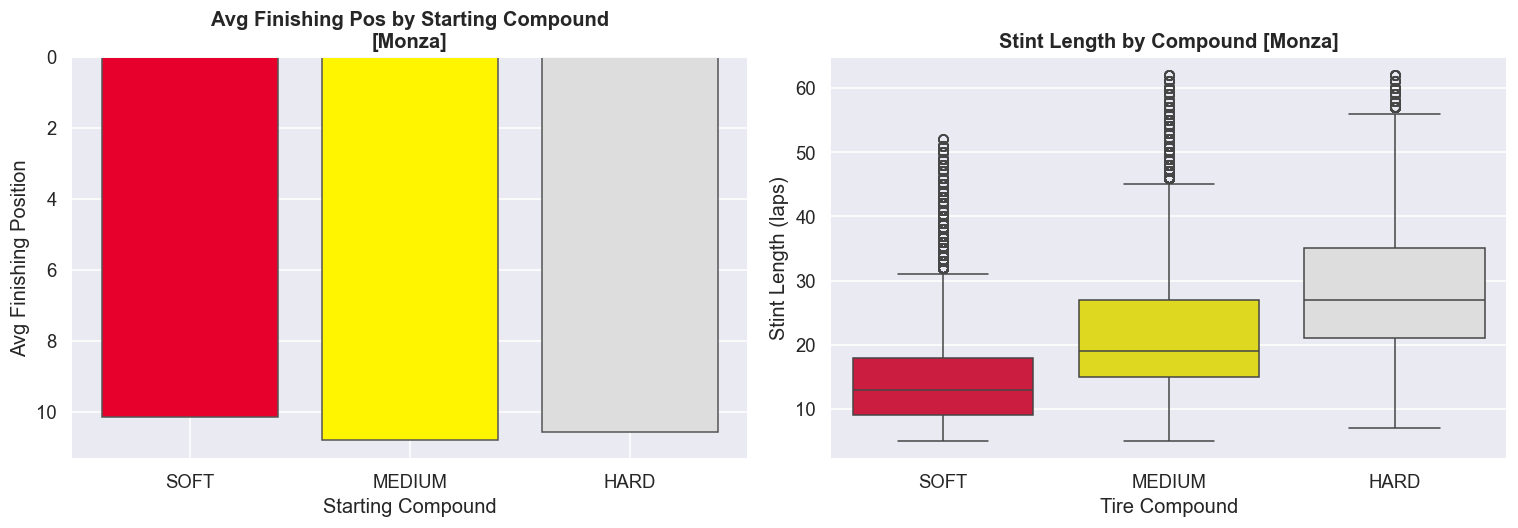

In [32]:
track_start = track_stints[track_stints["stint_number"] == 1].copy()
track_avg   = track_start.groupby("tire_compound", observed=True)["finishing_pos"].mean().reindex(TIRE_ORDER)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

colors_list = [TIRE_COLORS[c] for c in track_avg.index]
axes[0].bar(track_avg.index, track_avg.values, color=colors_list, edgecolor="#555")
axes[0].set_title(f"Avg Finishing Pos by Starting Compound\n[{FOCUS_TRACK}]", fontweight="bold")
axes[0].set_xlabel("Starting Compound")
axes[0].set_ylabel("Avg Finishing Position")
axes[0].invert_yaxis()

sns.boxplot(data=track_stints, x="tire_compound", y="stint_laps",
            order=TIRE_ORDER, palette=TIRE_COLORS, ax=axes[1])
axes[1].set_title(f"Stint Length by Compound [{FOCUS_TRACK}]", fontweight="bold")
axes[1].set_xlabel("Tire Compound")
axes[1].set_ylabel("Stint Length (laps)")

plt.tight_layout()
plt.show()

---
## §9 — Key Observations

Fill in your findings after running all cells above:

| Topic | Finding |
|-------|---------|
| **Tire speed ranking** | SOFT < MEDIUM < HARD (lap time) — to be verified |
| **Tire degradation** | SOFT degrades fastest; HARD slowest — to be verified |
| **Temperature effect** | Higher temp → more pit stops? |
| **Optimal pit lap** | Winners in 1-stop races pit around X% through the race |
| **Best 1-stop strategy** | ??? → ??? currently dominates |
| **Pit lane time range** | ? – ? s across tracks |

### Formula Hypothesis

```
lap_time(compound, lap_on_tire, base, temp) =
    base
    + compound_offset[compound]
    + degradation_rate[compound] * lap_on_tire
    + temp_factor * (temp - BASELINE_TEMP)
```

Use the patterns above to estimate each parameter.